# Rheology Analysis v3 — Universal Master Curve & Viscosity Extraction

End-to-end pipeline for the custom cone–plate gap-sweep data in `height_normalized.csv`.

**Pipeline**

1. Load the dataset and parse metadata from column headers.
2. Compute the drag signal `D(h) = T / RPM` for every fluid.
3. Per-fluid fits — hyperbolic `A/h+B`, regularised `A/(h+h0)+B`, log–log power law.
4. Diagnostics — residuals, normality (Shapiro–Wilk), local slope.
5. Master curve collapse — `D / D_max` vs `h`, global regularised fit → universal `h_c`.
6. Amplitude calibration — `A(μ)` against nominal viscosity → forward model.
7. Inverse predictor — given a new `D(h)` curve, recover `μ̂`.
8. Newtonian / non-Newtonian extension — protocol for multi-RPM sweeps.


In [68]:
"""Imports & global settings."""
from __future__ import annotations

import re
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

DATA_PATH = Path("height_normalized.csv")
OUT_DIR = Path("outputs_rheology")
FIG_DIR = Path("figures_rheology")
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Cone–plate geometry
R_CONE_MM   = 12.0
CONE_ANGLE_DEG = 3.0
CONE_ANGLE_RAD = np.deg2rad(CONE_ANGLE_DEG)
print(f"Geometry: R = {R_CONE_MM} mm, alpha = {CONE_ANGLE_DEG} deg ({CONE_ANGLE_RAD:.4f} rad)")


Geometry: R = 12.0 mm, alpha = 3.0 deg (0.0524 rad)


## 1. Load data & parse column metadata

Column headers encode `<nominal_kcP>_<ref_torque%>_torque_%_rpm_<rpm>`. We parse these
into a metadata table and reshape the dataset to a long-form table indexed by
`(fluid_id, h, torque_pct, rpm, D)`.


In [69]:
_HDR_RX = re.compile(
    r"^(?P<label>[\d\.]+)kcp_(?P<mu_true_kcp>[\d\.]+)_torque_%_rpm_(?P<rpm>[\d\.]+)$",
    flags=re.IGNORECASE,
)

def parse_header(col: str) -> dict | None:
    """Parse a column header of the form '<nom>kcp_<true_kcp>_torque_%_rpm_<rpm>'.

    NOTE: the SECOND number is the measured / true viscosity in kcP.
    The first number is only the nominal-bin label of the sample.
    """
    m = _HDR_RX.match(col.strip())
    if not m:
        return None
    nom_kcp  = float(m["label"])
    true_kcp = float(m["mu_true_kcp"])
    return {
        "column": col,
        "label": f"{nom_kcp}kcP",                 # display label (nominal bin)
        "mu_nom_label_cP": nom_kcp * 1000.0,      # nominal bin in cP (display only)
        "mu_true_cP": true_kcp * 1000.0,          # TRUE viscosity used for analysis
        "mu_nom_cP": true_kcp * 1000.0,           # alias for back-compat downstream
        "rpm": float(m["rpm"]),
    }

df_raw = pd.read_csv(DATA_PATH)
h_col = df_raw.columns[0]
fluid_cols = [c for c in df_raw.columns[1:] if parse_header(c) is not None]

meta = (pd.DataFrame([parse_header(c) for c in fluid_cols])
          .sort_values("mu_true_cP")
          .reset_index(drop=True))
meta["fluid_id"] = meta["label"]
print(f"Loaded {len(meta)} fluids, h grid has {len(df_raw)} points")
print("\nNominal bin label vs TRUE viscosity (cP):")
print(meta[["fluid_id", "mu_nom_label_cP", "mu_true_cP", "rpm"]].to_string(index=False))


Loaded 23 fluids, h grid has 31 points

Nominal bin label vs TRUE viscosity (cP):
fluid_id  mu_nom_label_cP  mu_true_cP  rpm
  1.0kcP           1000.0      1073.0 47.0
  2.0kcP           2000.0      3345.0 15.0
  5.0kcP           5000.0      5861.0  9.0
  4.0kcP           4000.0      6603.0  8.0
  8.0kcP           8000.0      8946.0  5.6
 10.0kcP          10000.0      9152.0  5.5
 12.5kcP          12500.0     14576.0  3.5
 15.0kcP          15000.0     19036.0  2.6
 25.0kcP          25000.0     22760.0  2.2
 20.0kcP          20000.0     24396.0  2.1
 30.0kcP          30000.0     31903.0  1.7
 45.0kcP          45000.0     40820.0  1.2
 55.0kcP          55000.0     48553.0  1.0
 40.0kcP          40000.0     62756.0  0.8
 35.0kcP          35000.0     63253.0  0.8
 60.0kcP          60000.0     68953.0  0.8
 75.0kcP          75000.0     70730.0  0.7
 50.0kcP          50000.0     79653.0  0.6
 70.0kcP          70000.0     87046.0  0.5
 95.0kcP          95000.0     93400.0  0.5
 90.0kcP       

In [70]:
def build_long(df_raw: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    """Reshape wide CSV into a long table with columns:
        fluid_id, mu_nom_cP, rpm, h, torque_pct, D
    `D = torque_pct / RPM` (raw drag signal in % per RPM).
    Rows with missing torque (the manually-trimmed contact/no-contact regions)
    are dropped.
    """
    rows = []
    h_arr = df_raw[h_col].to_numpy(dtype=float)
    for _, m in meta.iterrows():
        y = df_raw[m["column"]].to_numpy(dtype=float)
        mask = np.isfinite(y) & (y > 0)
        rows.append(pd.DataFrame({
            "fluid_id":   m["fluid_id"],
            "mu_nom_cP":  m["mu_nom_cP"],
            "rpm":        m["rpm"],
            "h":          h_arr[mask],
            "torque_pct": y[mask],
            "D":          y[mask] / m["rpm"],
        }))
    return pd.concat(rows, ignore_index=True)

long = build_long(df_raw, meta)
print(long.head())
print(f"\nTotal data points: {len(long)}")
print(long.groupby('fluid_id').size().rename('n_points').describe().round(1))


  fluid_id  mu_nom_cP   rpm     h  torque_pct         D
0   1.0kcP     1073.0  47.0  0.00    1.535177  0.032663
1   1.0kcP     1073.0  47.0  0.02    1.393901  0.029657
2   1.0kcP     1073.0  47.0  0.04    1.318369  0.028050
3   1.0kcP     1073.0  47.0  0.06    1.256525  0.026735
4   1.0kcP     1073.0  47.0  0.08    1.196525  0.025458

Total data points: 448
count    23.0
mean     19.5
std       3.0
min      12.0
25%      18.0
50%      19.0
75%      22.0
max      26.0
Name: n_points, dtype: float64


## 2. Raw visualisation — `D(h)` for all fluids


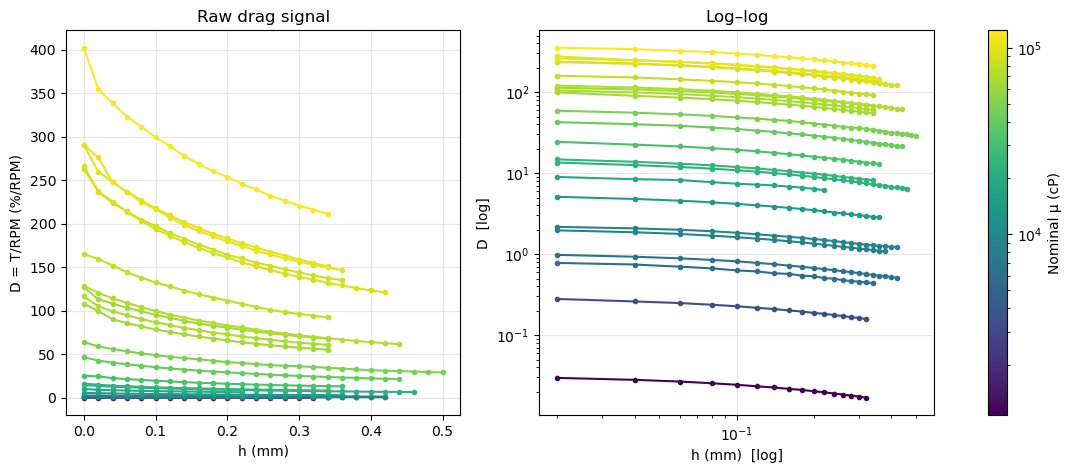

In [71]:
def _cmap_for(meta: pd.DataFrame):
    mus = meta["mu_nom_cP"].to_numpy()
    norm = plt.matplotlib.colors.LogNorm(vmin=mus.min(), vmax=mus.max())
    cmap = plt.cm.viridis
    return cmap, norm

cmap, norm = _cmap_for(meta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for _, m in meta.iterrows():
    sub = long[long.fluid_id == m.fluid_id]
    c = cmap(norm(m.mu_nom_cP))
    axes[0].plot(sub.h, sub.D, "o-", ms=3, color=c, label=m.label)
    axes[1].loglog(sub.h.replace(0, np.nan), sub.D, "o-", ms=3, color=c)
axes[0].set(xlabel="h (mm)", ylabel="D = T/RPM (%/RPM)", title="Raw drag signal")
axes[1].set(xlabel="h (mm)  [log]", ylabel="D  [log]", title="Log–log")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=axes, label="Nominal μ (cP)")
fig.savefig(FIG_DIR / "01_raw_drag.png", dpi=130, bbox_inches="tight")
plt.show()


## 3. Per-fluid model fits

Three families are fit to every fluid:

* **Hyperbolic** &nbsp; `D = A/h + B`  (lubrication ansatz, predicts log–log slope −1)
* **Regularised hyperbola** &nbsp; `D = A/(h+h0) + B`  (introduces a length scale `h0`)
* **Log–log power law** &nbsp; `log D = log A − n·log h`  (extracts the empirical slope `m = −n`)

For every fit we record the parameters, R², RMSE, and the Shapiro–Wilk p-value
of the residuals as a normality diagnostic.


In [72]:
# -------- model definitions --------
def model_hyper(h, A, B):
    return A / np.maximum(h, 1e-9) + B

def model_reg(h, A, h0, B):
    return A / (h + h0) + B

def model_powerlaw_log(logh, logA, n):
    return logA - n * logh

# -------- fitting helpers --------
@dataclass
class FitResult:
    name: str
    params: dict
    rmse: float
    r2: float
    shapiro_p: float
    residuals: np.ndarray

def _fit_metrics(name, params, h, D, pred):
    res = D - pred
    ss_res = float(np.sum(res ** 2))
    ss_tot = float(np.sum((D - D.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean(res ** 2)))
    sw_p = float(stats.shapiro(res).pvalue) if len(res) >= 3 else np.nan
    return FitResult(name, params, rmse, r2, sw_p, res)

def fit_one_fluid(h, D):
    out = {}
    # hyperbolic
    try:
        p, _ = curve_fit(model_hyper, h, D, p0=[D.max() * h.mean(), 0.0], maxfev=8000)
        out["hyper"] = _fit_metrics("hyper", dict(A=p[0], B=p[1]), h, D, model_hyper(h, *p))
    except Exception:
        out["hyper"] = None
    # regularised
    try:
        p, _ = curve_fit(model_reg, h, D,
                         p0=[D.max() * 0.3, 0.3, 0.0],
                         bounds=([0, 1e-3, -np.inf], [np.inf, 5.0, np.inf]),
                         maxfev=10000)
        out["reg"] = _fit_metrics("reg", dict(A=p[0], h0=p[1], B=p[2]), h, D, model_reg(h, *p))
    except Exception:
        out["reg"] = None
    # log–log power law (h > 0 only)
    mask = h > 0
    try:
        p, _ = curve_fit(model_powerlaw_log, np.log(h[mask]), np.log(D[mask]),
                         p0=[np.log(D.max()), 0.3])
        pred_log = model_powerlaw_log(np.log(h[mask]), *p)
        out["pl"] = _fit_metrics("pl", dict(logA=p[0], n=p[1]),
                                  h[mask], np.log(D[mask]), pred_log)
    except Exception:
        out["pl"] = None
    return out

# -------- run over all fluids --------
fits = {}
rows = []
for fid in meta.fluid_id:
    sub = long[long.fluid_id == fid].sort_values("h")
    h = sub.h.to_numpy(); D = sub.D.to_numpy()
    if len(h) < 5:
        continue
    fits[fid] = fit_one_fluid(h, D)
    for name, fr in fits[fid].items():
        if fr is None:
            continue
        row = {"fluid_id": fid, "model": name,
               "rmse": fr.rmse, "r2": fr.r2, "shapiro_p": fr.shapiro_p}
        row.update(fr.params)
        rows.append(row)

fit_table = pd.DataFrame(rows)
fit_table = fit_table.merge(meta[["fluid_id", "mu_nom_cP", "rpm"]], on="fluid_id")
fit_table.to_csv(OUT_DIR / "per_fluid_fits.csv", index=False)
fit_table.head(20)


,fluid_id,model,rmse,r2,shapiro_p,A,B,h0,logA,n,mu_nom_cP,rpm
0,1.0kcP,hyper,0.003695,0.314093,0.511310,1.062557e-11,0.022038,NaN,NaN,NaN,1073.0,47.0
1,1.0kcP,reg,0.000209,0.997813,0.817496,6.031801e-03,0.006209,0.232402,NaN,NaN,1073.0,47.0
2,1.0kcP,pl,0.044009,0.932555,0.114827,NaN,NaN,NaN,-4.256801,0.214168,1073.0,47.0
3,2.0kcP,hyper,0.034765,0.324107,0.468032,1.023157e-10,0.205329,NaN,NaN,NaN,3345.0,15.0
4,2.0kcP,reg,0.001967,0.997836,0.798359,4.870223e-02,0.067563,0.206575,NaN,NaN,3345.0,15.0
5,2.0kcP,pl,0.041542,0.940614,0.203435,NaN,NaN,NaN,-2.029560,0.216374,3345.0,15.0
6,5.0kcP,hyper,0.100497,0.258054,0.218929,2.587437e-10,0.567429,NaN,NaN,NaN,5861.0,9.0
7,5.0kcP,reg,0.004281,0.998653,0.551440,1.813145e-01,0.133210,0.260464,NaN,NaN,5861.0,9.0
8,5.0kcP,pl,0.042362,0.942689,0.112875,NaN,NaN,NaN,-1.014591,0.222551,5861.0,9.0
9,4.0kcP,hyper,0.135480,0.244429,0.136240,3.699355e-10,0.685377,NaN,NaN,NaN,6603.0,8.0


In [73]:
# Summary by model
summary = (fit_table.groupby("model")
           .agg(rmse_mean=("rmse", "mean"),
                r2_mean=("r2", "mean"),
                shapiro_p_median=("shapiro_p", "median"))
           .sort_values("r2_mean", ascending=False))
print("=== Model summary ===")
print(summary.round(4))

# Slope universality (log–log)
pl = fit_table[fit_table.model == "pl"].sort_values("mu_nom_cP")
print(f"\nPower-law slope m = -n :  mean = {-pl.n.mean():.3f}  std = {pl.n.std():.3f}")
print(f"h0 from regularised fit:  mean = {fit_table.query('model==\"reg\"').h0.mean():.3f} mm  "
      f"std = {fit_table.query('model==\"reg\"').h0.std():.3f}")


=== Model summary ===
       rmse_mean  r2_mean  shapiro_p_median
model                                      
reg       0.7388   0.9978            0.1291
pl        0.0435   0.9404            0.1490
hyper    11.7650   0.2886            0.2424

Power-law slope m = -n :  mean = -0.221  std = 0.022
h0 from regularised fit:  mean = 0.234 mm  std = 0.046


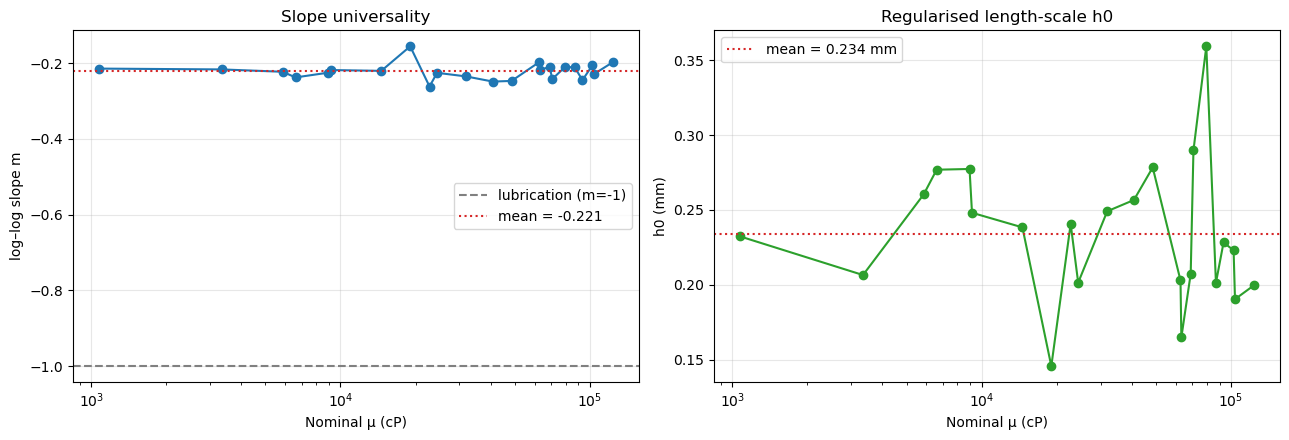

In [74]:
# Slope and h0 plots vs viscosity
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pl_t  = fit_table[fit_table.model == "pl"].sort_values("mu_nom_cP")
reg_t = fit_table[fit_table.model == "reg"].sort_values("mu_nom_cP")

axes[0].semilogx(pl_t.mu_nom_cP, -pl_t.n, "o-", color="C0")
axes[0].axhline(-1, ls="--", color="grey", label="lubrication (m=-1)")
axes[0].axhline(-pl_t.n.mean(), ls=":", color="C3", label=f"mean = {-pl_t.n.mean():.3f}")
axes[0].set(xlabel="Nominal μ (cP)", ylabel="log–log slope m",
            title="Slope universality")
axes[0].legend()

axes[1].semilogx(reg_t.mu_nom_cP, reg_t.h0, "o-", color="C2")
axes[1].axhline(reg_t.h0.mean(), ls=":", color="C3",
                label=f"mean = {reg_t.h0.mean():.3f} mm")
axes[1].set(xlabel="Nominal μ (cP)", ylabel="h0 (mm)",
            title="Regularised length-scale h0")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "02_slope_h0.png", dpi=130, bbox_inches="tight")
plt.show()


## 4. Master curve collapse

Normalise every dataset by its own maximum, plot together, and compute the
mean ± 1σ envelope. A single regularised hyperbola is then fit to the pooled
data — its parameter `h_c` is the **universal geometry length scale**.


In [75]:
# Build a normalised (D / Dmax) long table
long_norm = long.copy()
long_norm["D_norm"] = long_norm["D"] / long_norm.groupby("fluid_id")["D"].transform("max")

# Bin onto the canonical h grid for a mean/std envelope
h_grid = np.sort(df_raw[h_col].unique())
mean_curve, std_curve, n_curve = [], [], []
for hv in h_grid:
    vals = long_norm.loc[np.isclose(long_norm.h, hv), "D_norm"].to_numpy()
    if len(vals) >= 2:
        mean_curve.append(vals.mean()); std_curve.append(vals.std()); n_curve.append(len(vals))
    else:
        mean_curve.append(np.nan); std_curve.append(np.nan); n_curve.append(len(vals))
master = pd.DataFrame({"h": h_grid, "D_norm_mean": mean_curve,
                       "D_norm_std": std_curve, "n": n_curve}).dropna()
master.head()


,h,D_norm_mean,D_norm_std,n
0,0.00,1.000000,0.000000,23
1,0.02,0.920115,0.022505,23
2,0.04,0.866272,0.021312,23
3,0.06,0.826027,0.019227,23
4,0.08,0.788520,0.018417,23


Universal reg fit (no B):   a=0.3796, h_c=0.3946 mm
Universal reg fit (with B): a=0.2026, h_c=0.2504 mm, B=0.1778


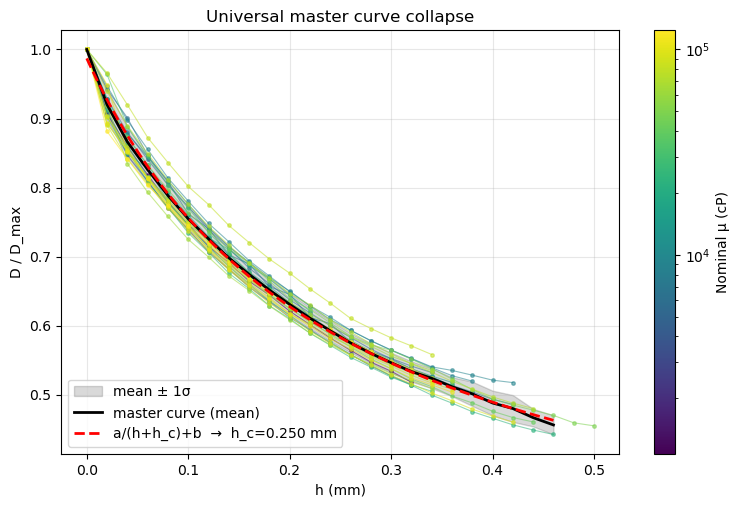


>>> Adopted universal length scale h_c = 0.2504 mm


In [76]:
# Global fits to the normalised master curve
def model_reg_norm(h, a, h0):
    return a / (h + h0)

def model_reg_norm_b(h, a, h0, b):
    return a / (h + h0) + b

x = master.h.to_numpy(); y = master.D_norm_mean.to_numpy()
p_a,  _ = curve_fit(model_reg_norm,   x, y, p0=[1.0, 0.3], maxfev=10000)
p_ab, _ = curve_fit(model_reg_norm_b, x, y, p0=[1.0, 0.3, 0.1], maxfev=10000)

print(f"Universal reg fit (no B):   a={p_a[0]:.4f}, h_c={p_a[1]:.4f} mm")
print(f"Universal reg fit (with B): a={p_ab[0]:.4f}, h_c={p_ab[1]:.4f} mm, B={p_ab[2]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))
for _, m in meta.iterrows():
    sub = long_norm[long_norm.fluid_id == m.fluid_id].sort_values("h")
    ax.plot(sub.h, sub.D_norm, "o-", ms=2.5, lw=0.8,
            color=cmap(norm(m.mu_nom_cP)), alpha=0.55)
ax.fill_between(master.h,
                master.D_norm_mean - master.D_norm_std,
                master.D_norm_mean + master.D_norm_std,
                color="k", alpha=0.15, label="mean ± 1σ")
ax.plot(master.h, master.D_norm_mean, "k-", lw=2, label="master curve (mean)")
xx = np.linspace(0, x.max(), 200)
ax.plot(xx, model_reg_norm_b(xx, *p_ab), "r--", lw=2,
        label=f"a/(h+h_c)+b  →  h_c={p_ab[1]:.3f} mm")
ax.set(xlabel="h (mm)", ylabel="D / D_max",
       title="Universal master curve collapse")
ax.legend(loc="lower left")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax, label="Nominal μ (cP)")
fig.savefig(FIG_DIR / "03_master_curve.png", dpi=130, bbox_inches="tight")
plt.show()

H_C_UNIVERSAL = float(p_ab[1])
print(f"\n>>> Adopted universal length scale h_c = {H_C_UNIVERSAL:.4f} mm")


## 5. Amplitude calibration  `A(μ)`

With `h_c` fixed at the universal value from §4, each fluid is refit as
`D = A / (h + h_c) + B`. The amplitude `A` is then plotted against the
nominal viscosity to build the forward calibration.

Two functional forms are tried:

* linear &nbsp;&nbsp; `A = k · μ`
* power &nbsp;&nbsp; `A = k · μ^p`

The chosen calibration is the inverse map used later for prediction.


In [77]:
def model_reg_fixed_hc(h, A, B, hc=H_C_UNIVERSAL):
    return A / (h + hc) + B

amp_rows = []
for fid in meta.fluid_id:
    sub = long[long.fluid_id == fid].sort_values("h")
    if len(sub) < 4:
        continue
    h = sub.h.to_numpy(); D = sub.D.to_numpy()
    try:
        p, _ = curve_fit(lambda h, A, B: model_reg_fixed_hc(h, A, B),
                         h, D, p0=[D.max() * H_C_UNIVERSAL, 0.0], maxfev=10000)
        pred = model_reg_fixed_hc(h, *p)
        ss_res = float(np.sum((D - pred) ** 2))
        ss_tot = float(np.sum((D - D.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        mu = float(meta.loc[meta.fluid_id == fid, "mu_nom_cP"].iloc[0])
        rpm = float(meta.loc[meta.fluid_id == fid, "rpm"].iloc[0])
        amp_rows.append({"fluid_id": fid, "mu_nom_cP": mu, "rpm": rpm,
                         "A": p[0], "B": p[1], "r2": r2})
    except Exception:
        pass

amp = pd.DataFrame(amp_rows).sort_values("mu_nom_cP").reset_index(drop=True)
amp["A_per_rpm"] = amp["A"]  # already T/RPM scaled; rename for clarity
amp.to_csv(OUT_DIR / "amplitudes.csv", index=False)
amp


,fluid_id,mu_nom_cP,rpm,A,B,r2,A_per_rpm
0,1.0kcP,1073.0,47.0,0.006690,0.005325,0.997684,0.006690
1,2.0kcP,3345.0,15.0,0.063388,0.047059,0.996938,0.063388
2,5.0kcP,5861.0,9.0,0.171654,0.145476,0.998614,0.171654
3,4.0kcP,6603.0,8.0,0.215978,0.191620,0.999301,0.215978
4,8.0kcP,8946.0,5.6,0.421663,0.409349,0.999583,0.421663
5,10.0kcP,9152.0,5.5,0.456507,0.520865,0.998236,0.456507
6,12.5kcP,14576.0,3.5,1.109878,1.010524,0.999511,1.109878
7,15.0kcP,19036.0,2.6,1.848651,2.246048,0.986931,1.848651
8,25.0kcP,22760.0,2.2,3.090493,2.072345,0.999334,3.090493
9,20.0kcP,24396.0,2.1,3.365551,2.372858,0.997751,3.365551


Linear  A = 4.933e-04 * mu      | RMSE = 8.039
Power   A = 5.087e-09 * mu^2.007 | R^2 = 0.9990 | RMSE = 3.261


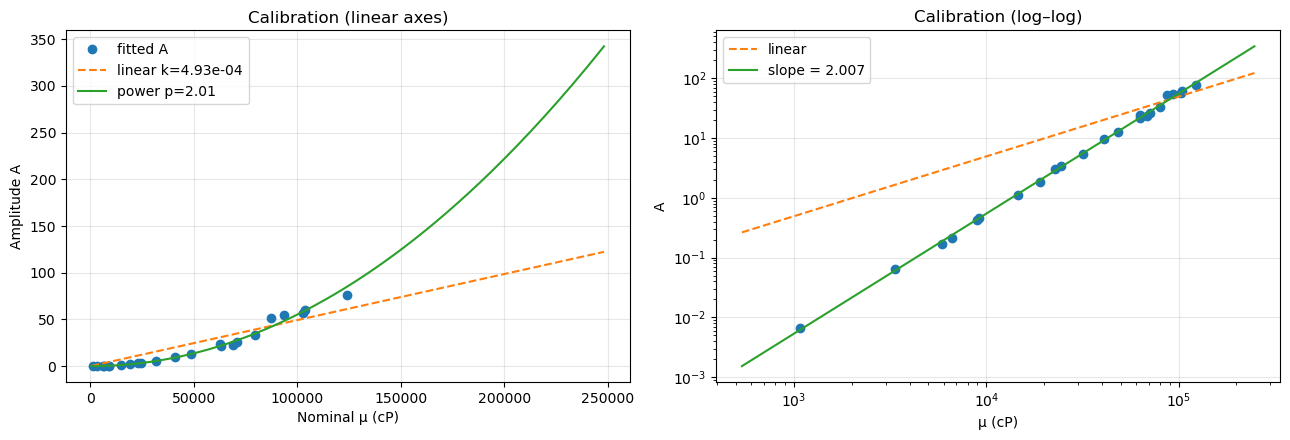

{'h_c': 0.2503872153342105,
 'linear': {'k': 0.0004932676926901428, 'rmse': 8.038978925446708},
 'power': {'k': 5.086609159736151e-09,
  'p': 2.0072284008949497,
  'rmse': 3.2612562719716744,
  'r2': np.float64(0.998952790864571)}}

In [78]:
# Fit two calibration laws on (mu_nom_cP, A)
mu = amp.mu_nom_cP.to_numpy()
A  = amp.A.to_numpy()

# linear  A = k * mu  (forced through origin)
k_lin, *_ = np.linalg.lstsq(mu.reshape(-1, 1), A, rcond=None)
k_lin = float(k_lin[0])

# power  A = k * mu^p   (log-log regression)
slope, intercept, r_pow, *_ = stats.linregress(np.log(mu), np.log(A))
p_exp = float(slope); k_pow = float(np.exp(intercept))

# Predictions on the calibration set
A_lin_pred = k_lin * mu
A_pow_pred = k_pow * mu ** p_exp
rmse_lin = float(np.sqrt(np.mean((A - A_lin_pred) ** 2)))
rmse_pow = float(np.sqrt(np.mean((A - A_pow_pred) ** 2)))

print(f"Linear  A = {k_lin:.3e} * mu      | RMSE = {rmse_lin:.3f}")
print(f"Power   A = {k_pow:.3e} * mu^{p_exp:.3f} | R^2 = {r_pow**2:.4f} | RMSE = {rmse_pow:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mu_grid = np.geomspace(mu.min() / 2, mu.max() * 2, 200)

axes[0].plot(mu, A, "o", label="fitted A")
axes[0].plot(mu_grid, k_lin * mu_grid, "--", label=f"linear k={k_lin:.2e}")
axes[0].plot(mu_grid, k_pow * mu_grid ** p_exp, "-",
             label=f"power p={p_exp:.2f}")
axes[0].set(xlabel="Nominal μ (cP)", ylabel="Amplitude A",
            title="Calibration (linear axes)")
axes[0].legend()

axes[1].loglog(mu, A, "o")
axes[1].loglog(mu_grid, k_lin * mu_grid, "--", label="linear")
axes[1].loglog(mu_grid, k_pow * mu_grid ** p_exp, "-",
                label=f"slope = {p_exp:.3f}")
axes[1].set(xlabel="μ (cP)", ylabel="A", title="Calibration (log–log)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_calibration.png", dpi=130, bbox_inches="tight")
plt.show()

CALIBRATION = {
    "h_c": H_C_UNIVERSAL,
    "linear": {"k": k_lin, "rmse": rmse_lin},
    "power":  {"k": k_pow, "p": p_exp, "rmse": rmse_pow, "r2": r_pow**2},
}
CALIBRATION


## 6. Inverse predictor `μ̂(D(h))`

Given a fresh gap sweep `(h, torque%, RPM)`, the predictor:

1. computes `D = T / RPM`,
2. fits `D = A/(h + h_c) + B` with `h_c` fixed at the universal value,
3. converts amplitude → viscosity via the inverse of the chosen calibration.

A leave-one-out cross validation on the calibration set quantifies the
expected accuracy.


In [79]:
def fit_amplitude(h, D, hc=H_C_UNIVERSAL):
    """Fit the universal regularised hyperbola, return (A, B, r2)."""
    p, _ = curve_fit(lambda h, A, B: A / (h + hc) + B, h, D,
                     p0=[max(D) * hc, 0.0], maxfev=10000)
    pred = p[0] / (h + hc) + p[1]
    ss_res = float(np.sum((D - pred) ** 2))
    ss_tot = float(np.sum((D - D.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(p[0]), float(p[1]), float(r2)

def predict_viscosity(h, torque_pct, rpm, calibration=CALIBRATION, kind="power"):
    """Return (mu_hat, A, B, r2)."""
    h = np.asarray(h, dtype=float); t = np.asarray(torque_pct, dtype=float)
    mask = np.isfinite(t) & (t > 0)
    D = t[mask] / float(rpm)
    A, B, r2 = fit_amplitude(h[mask], D, hc=calibration["h_c"])
    if kind == "linear":
        mu_hat = A / calibration["linear"]["k"]
    else:
        mu_hat = (A / calibration["power"]["k"]) ** (1.0 / calibration["power"]["p"])
    return float(mu_hat), A, B, r2

# Leave-one-out CV
loo_rows = []
for i in range(len(amp)):
    train = amp.drop(index=i)
    test  = amp.iloc[i]
    slope, intercept, *_ = stats.linregress(np.log(train.mu_nom_cP), np.log(train.A))
    mu_hat_pow = (test.A / np.exp(intercept)) ** (1.0 / slope)
    k_lin_loo  = float((train.A * train.mu_nom_cP).sum() / (train.mu_nom_cP ** 2).sum())
    mu_hat_lin = test.A / k_lin_loo
    loo_rows.append({"fluid_id": test.fluid_id, "mu_true": test.mu_nom_cP,
                     "mu_hat_power": mu_hat_pow, "mu_hat_linear": mu_hat_lin})

loo = pd.DataFrame(loo_rows)
loo["err_pct_power"]  = 100 * (loo.mu_hat_power  - loo.mu_true) / loo.mu_true
loo["err_pct_linear"] = 100 * (loo.mu_hat_linear - loo.mu_true) / loo.mu_true
loo.to_csv(OUT_DIR / "loo_cv.csv", index=False)
print("Leave-one-out CV (% error):")
print(loo[["fluid_id","mu_true","mu_hat_power","err_pct_power",
           "mu_hat_linear","err_pct_linear"]].round(2).to_string(index=False))
print(f"\nMedian |err| power  = {loo.err_pct_power.abs().median():.2f}%")
print(f"Median |err| linear = {loo.err_pct_linear.abs().median():.2f}%")


Leave-one-out CV (% error):
fluid_id  mu_true  mu_hat_power  err_pct_power  mu_hat_linear  err_pct_linear
  1.0kcP   1073.0       1141.66           6.40          13.56          -98.74
  2.0kcP   3345.0       3444.75           2.98         128.49          -96.16
  5.0kcP   5861.0       5601.84          -4.42         347.86          -94.06
  4.0kcP   6603.0       6280.69          -4.88         437.64          -93.37
  8.0kcP   8946.0       8799.00          -1.64         854.10          -90.45
 10.0kcP   9152.0       9167.40           0.17         924.64          -89.90
 12.5kcP  14576.0      14251.61          -2.23        2245.24          -84.60
 15.0kcP  19036.0      18367.71          -3.51        3734.77          -80.38
 25.0kcP  22760.0      23815.42           4.64        6237.29          -72.60
 20.0kcP  24396.0      24817.52           1.73        6788.07          -72.18
 30.0kcP  31903.0      31269.04          -1.99       10797.91          -66.15
 45.0kcP  40820.0      41919.98     

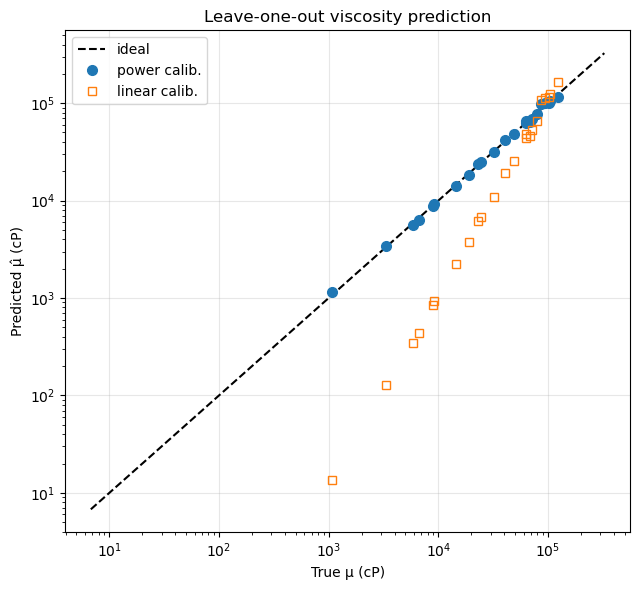

In [80]:
# Parity plot
fig, ax = plt.subplots(figsize=(6.5, 6))
lims = [loo[["mu_true","mu_hat_power","mu_hat_linear"]].min().min() * 0.5,
        loo[["mu_true","mu_hat_power","mu_hat_linear"]].max().max() * 2]
ax.loglog(lims, lims, "k--", label="ideal")
ax.loglog(loo.mu_true, loo.mu_hat_power,  "o", ms=7, label="power calib.")
ax.loglog(loo.mu_true, loo.mu_hat_linear, "s", ms=6, mfc="none", label="linear calib.")
ax.set(xlabel="True μ (cP)", ylabel="Predicted μ̂ (cP)",
       title="Leave-one-out viscosity prediction")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05_loo_parity.png", dpi=130, bbox_inches="tight")
plt.show()


## 7. Newtonian / Non-Newtonian classification

The present dataset has **a single RPM per fluid**, so a true power-law
index `n` cannot be extracted here — it requires running the gap sweep at
several RPMs. The procedure is implemented below as a reusable function:

For an ideal cone–plate, shear rate is

$$ \dot{\gamma} = \omega / \alpha \quad\text{(independent of } h \text{)} $$

and for a power-law fluid `τ = K γ̇ⁿ`,

$$ \frac{T}{\mathrm{RPM}} \propto \mathrm{RPM}^{\,n-1}. $$

So fitting `log A` vs `log RPM` across an RPM sweep gives `n − 1` (slope)
and a constant proportional to `K` (intercept). `n ≈ 1` → Newtonian.

For diagnostic purposes here, we use the calibration residuals: fluids that
deviate substantially from the silicone `A(μ)` trend are flagged as candidate
non-Newtonian (or non-silicone) samples.


In [81]:
def shear_rate_from_rpm(rpm: float, alpha_rad: float = CONE_ANGLE_RAD) -> float:
    """Shear rate of an ideal cone-plate at given RPM (s^-1)."""
    omega = 2 * np.pi * rpm / 60.0
    return omega / alpha_rad

def fit_power_law(rpm_arr, A_arr) -> dict:
    """Given amplitudes extracted at multiple RPMs for the SAME fluid,
    return {'n': flow_index, 'K_proxy': consistency proxy, 'r2': float}.
    Slope of log A vs log RPM == n - 1.
    """
    rpm_arr = np.asarray(rpm_arr, float); A_arr = np.asarray(A_arr, float)
    s, intercept, r, *_ = stats.linregress(np.log(rpm_arr), np.log(A_arr))
    return {"n": float(s + 1.0),
            "K_proxy": float(np.exp(intercept)),
            "r2": float(r ** 2)}

def analyse_fluid(h, torque_pct, rpm, fluid_name="unknown",
                  calibration=CALIBRATION):
    """Full Newtonian-mode analysis for one gap sweep at one RPM.
    Returns dict with mu_hat, A, B, r2, shear_rate."""
    mu_hat, A, B, r2 = predict_viscosity(h, torque_pct, rpm, calibration)
    return {
        "fluid": fluid_name,
        "rpm": float(rpm),
        "shear_rate_s-1": shear_rate_from_rpm(float(rpm)),
        "A": A, "B": B, "r2": r2,
        "mu_hat_cP": mu_hat,
        "viscosity_Pa_s": mu_hat * 1e-3,
        "note": "Newtonian assumption (single RPM). For non-Newtonian, "
                "repeat at multiple RPMs and call fit_power_law().",
    }

# Demo on one fluid from the dataset
demo_fid = "12.5kcP"
demo = long[long.fluid_id == demo_fid].sort_values("h")
res = analyse_fluid(demo.h, demo.torque_pct, demo.rpm.iloc[0], demo_fid)
print("=== Demo: 12.5kcP silicone ===")
for k, v in res.items():
    print(f"  {k:18s}: {v}")


=== Demo: 12.5kcP silicone ===
  fluid             : 12.5kcP
  rpm               : 3.5
  shear_rate_s-1    : 7.0
  A                 : 1.1098776906329813
  B                 : 1.0105241543666685
  r2                : 0.9995108585673269
  mu_hat_cP         : 14269.49196730346
  viscosity_Pa_s    : 14.26949196730346
  note              : Newtonian assumption (single RPM). For non-Newtonian, repeat at multiple RPMs and call fit_power_law().


## 8. Residual & local-slope diagnostics

For the best (regularised) model on a chosen example fluid:
* residuals vs `h`
* QQ plot
* Shapiro–Wilk p-value
* local log–log slope  `d log D / d log h`


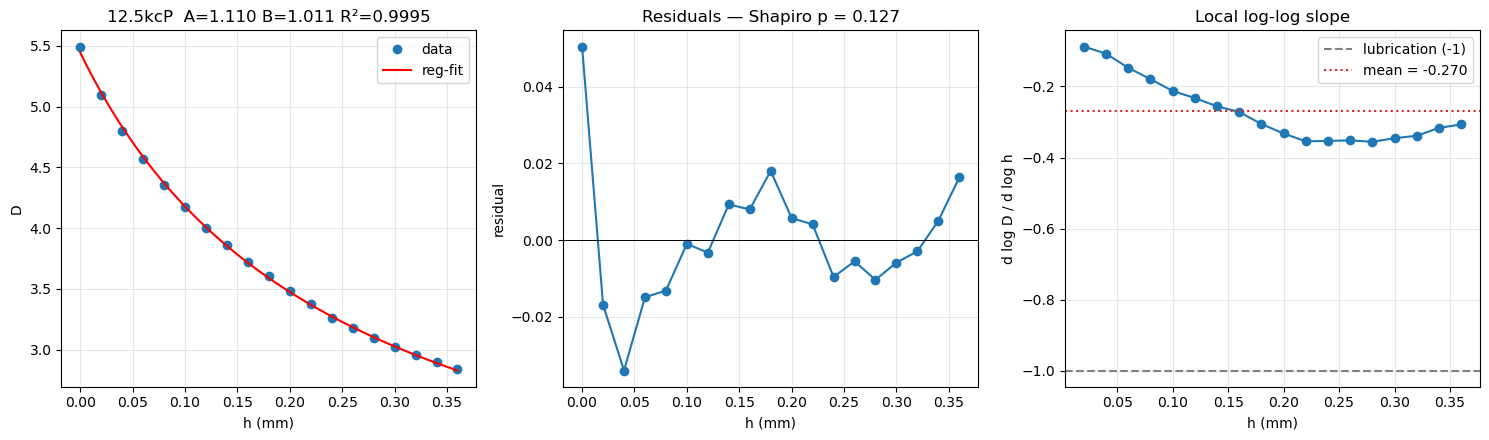

{'A': 1.1098776906329813,
 'B': 1.0105241543666685,
 'r2': 0.9995108585673269,
 'shapiro_p': np.float64(0.127191082003493),
 'local_slope_mean': -0.2697816440987557}

In [82]:
def diagnose(fluid_id: str):
    sub = long[long.fluid_id == fluid_id].sort_values("h")
    h, D = sub.h.to_numpy(), sub.D.to_numpy()
    A, B, r2 = fit_amplitude(h, D, hc=H_C_UNIVERSAL)
    pred = A / (h + H_C_UNIVERSAL) + B
    res  = D - pred
    sw_p = stats.shapiro(res).pvalue if len(res) >= 3 else np.nan

    # local slope using log-log finite differences
    m = h > 0
    lh, ld = np.log(h[m]), np.log(D[m])
    slope = np.gradient(ld, lh)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].plot(h, D, "o", label="data")
    hg = np.linspace(h.min(), h.max(), 200)
    axes[0].plot(hg, A / (hg + H_C_UNIVERSAL) + B, "r-", label="reg-fit")
    axes[0].set(xlabel="h (mm)", ylabel="D",
                title=f"{fluid_id}  A={A:.3f} B={B:.3f} R²={r2:.4f}")
    axes[0].legend()

    axes[1].plot(h, res, "o-")
    axes[1].axhline(0, color="k", lw=0.7)
    axes[1].set(xlabel="h (mm)", ylabel="residual",
                title=f"Residuals — Shapiro p = {sw_p:.3f}")

    axes[2].plot(h[m], slope, "o-")
    axes[2].axhline(-1, ls="--", color="grey", label="lubrication (-1)")
    axes[2].axhline(slope.mean(), ls=":", color="C3",
                    label=f"mean = {slope.mean():.3f}")
    axes[2].set(xlabel="h (mm)", ylabel="d log D / d log h",
                title="Local log-log slope")
    axes[2].legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"06_diagnostics_{fluid_id.replace('.','p')}.png",
                dpi=130, bbox_inches="tight")
    plt.show()
    return {"A": A, "B": B, "r2": r2, "shapiro_p": sw_p,
            "local_slope_mean": float(slope.mean())}

diagnose("12.5kcP")


## 9. Summary outputs

All key tables are written to `outputs_rheology/`:

* `per_fluid_fits.csv` &nbsp;— hyperbolic / regularised / power-law parameters per fluid.
* `amplitudes.csv` &nbsp;— amplitude `A` from the universal-`h_c` fit per fluid.
* `loo_cv.csv` &nbsp;— leave-one-out viscosity predictions and % errors.
* `calibration.json` &nbsp;— the adopted calibration coefficients.
* `master_curve.csv` &nbsp;— mean ± σ of the normalised drag at each `h`.

All figures are saved to `figures_rheology/`.


In [83]:
import json
master.to_csv(OUT_DIR / "master_curve.csv", index=False)
with open(OUT_DIR / "calibration.json", "w") as f:
    json.dump(CALIBRATION, f, indent=2)

print("Files written to", OUT_DIR.resolve())
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)
print("\nFigures in", FIG_DIR.resolve())
for p in sorted(FIG_DIR.glob("*")):
    print(" -", p.name)


Files written to C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\outputs_rheology
 - amplitudes.csv
 - bootstrap_100kcp_regularized.csv
 - bootstrap_12.5kcp_regularized.csv
 - bootstrap_25kcp_gen_power.csv
 - bootstrap_45kcp_regularized.csv
 - bootstrap_5kcp_regularized.csv
 - bootstrap_70kcp_regularized.csv
 - bootstrap_8kcp_gen_power.csv
 - bootstrap_90kcp_gen_power.csv
 - calibration.json
 - loo_cv.csv
 - master_curve.csv
 - master_curve_hc_per_sample.csv
 - master_curve_model_comparison.csv
 - master_curve_params.csv
 - metrics_100kcp_regularized.csv
 - metrics_12.5kcp_regularized.csv
 - metrics_25kcp_gen_power.csv
 - metrics_45kcp_regularized.csv
 - metrics_5kcp_regularized.csv
 - metrics_70kcp_regularized.csv
 - metrics_8kcp_gen_power.csv
 - metrics_90kcp_gen_power.csv
 - model_comparison_100kcp.csv
 - model_comparison_12.5kcp.csv
 - model_comparison_25kcp.csv
 - model_comparison_45kcp.csv
 - model_comparison_5kcp.csv
 - model_comparison_70kcp.csv


## 10. Non-Newtonian Validation — PEG, Sepineo and Solagum

We now apply the **exact same** universal-`F(h)` pipeline (`h_c = H_C_UNIVERSAL`,
amplitude calibration `μ̂ = (A / k)^(1/p)`) to three independently tested,
shear-thinning systems:

* **PEG** (polyethylene glycol) — 300 kDa and 600 kDa, several concentrations
  (5–10 %). Dilute *flexible-chain* polymer solutions.
* **Sepineo P-600** — three concentrations (1, 1.5, 2 %). Acrylate-class
  *associative gel* thickener.
* **Solagum AX** — three concentrations (1, 2, 3 %). Acacia / xanthan
  *natural-gum* thickener.

Differences from the silicone calibration set
* Data are stored as raw streaming records
  `(Z_Height_mm, RPM, Torque%, Rotational_Drag)` in absolute spindle coordinates.
  We must recover the gap by hit-point detection: `h = Z − Z_min` for every sweep.
* The instrument occasionally **auto-shifts RPM near contact** when torque
  saturates. Those points are not informative for a single-RPM amplitude fit and
  are filtered (we keep the dominant-RPM segment of each sweep).
* Sentinel rows written by the firmware (`SKIPPED`, `<25 %`) are coerced to NaN
  and dropped before fitting.
* Each non-Newtonian sample is acquired at a single RPM, so the predicted
  `μ̂` is the **apparent viscosity at that shear rate** `γ̇ = ω/α`.

The labelled viscosity embedded in the cell name (suffix `_<kcP>`) is the
manufacturer / low-shear reference and we use it as the ground truth for the
parity comparison below.


In [84]:
PEG_CSV = Path("all_PEG.csv")
SEP_CSV = Path("all_sepineo.csv")
SOL_CSV = Path("all_solagum.csv")

def parse_nn_label(label: str, source_hint: str | None = None) -> dict:
    """Parse a non-Newtonian sample label.

    Supports the patterns found in the supplied data:
        '5%300K_0.577'   ->  family='PEG-300K', conc='5%', true=577
        '300K5%_0.577'   ->  family='PEG-300K', conc='5%', true=577
        '300K_5%_PEG'    ->  family='PEG-300K', conc='5%', true=None
        '1%sep_2.148'    ->  family='Sepineo',  conc='1%',  true=2148
        '1%sola_0.522'   ->  family='Solagum',  conc='1%',  true=522
        '2%' / '1.50%'   ->  bare label, resolved using source_hint
                              (e.g. source_hint='Sepineo' -> family='Sepineo')
    Returns the family, concentration string and the labelled viscosity
    (in cP). `true_cP` is None if no number was embedded.
    """
    s = label.strip()
    true_kcp = None
    m = re.search(r"_(\d+(?:\.\d+)?)\s*$", s)
    if m:
        try:
            true_kcp = float(m.group(1))
            s_short = s[: m.start()]
        except ValueError:
            s_short = s
    else:
        s_short = s
    if re.search(r"sola", s_short, re.IGNORECASE):
        family = "Solagum"
    elif re.search(r"sep", s_short, re.IGNORECASE):
        family = "Sepineo"
    elif re.search(r"\d+\s*K", s_short, re.IGNORECASE):
        mw = re.search(r"(\d+)\s*K", s_short, re.IGNORECASE)
        family = f"PEG-{int(mw.group(1))}K" if mw else "PEG"
    elif s_short.strip("%").replace(".", "").isdigit() and source_hint:
        family = source_hint
    else:
        family = source_hint or "PEG"
    conc = re.search(r"(\d+(?:\.\d+)?)\s*%", s_short)
    conc_str = conc.group(1) + "%" if conc else "?"
    return {
        "raw_label": label,
        "family": family,
        "conc": conc_str,
        "true_cP": (true_kcp * 1000.0) if true_kcp is not None else np.nan,
    }

def _dominant_rpm(series: pd.Series) -> float:
    """Most common RPM in a sweep (drops auto-shift outliers)."""
    return float(series.value_counts().idxmax())

def load_nn_dataset(csv_path: Path, source_tag: str,
                    family_hint: str | None = None) -> pd.DataFrame:
    """Load a streaming CSV and return a long-form table with columns:
       source, fluid_id, family, conc, true_cP, rpm, h, torque_pct, D, shear_rate.
       `h` is recovered from absolute Z via h = Z - Z_min for each sweep.
       Rows whose RPM differs from the sweep's dominant RPM are dropped
       (instrument auto-shift near contact).  Sentinel strings such as
       'SKIPPED' / '<25%' are coerced to NaN and dropped.
    """
    raw = pd.read_csv(csv_path)
    for col in ("Torque_%", "Rotational_Drag", "Elapsed_Time_s"):
        if col in raw.columns:
            raw[col] = pd.to_numeric(raw[col], errors="coerce")
    out = []
    for (row_id, cell_id, label), grp in raw.groupby(["row", "cell", "Cell_Label"]):
        meta = parse_nn_label(label, source_hint=family_hint)
        rpm_dom = _dominant_rpm(grp["RPM"])
        seg = grp[np.isclose(grp["RPM"], rpm_dom)].copy()
        seg = seg.dropna(subset=["Rotational_Drag", "Torque_%"])
        if seg.empty:
            continue
        seg["h"] = seg["Z_Height_mm"] - seg["Z_Height_mm"].min()
        seg = seg.sort_values("h")
        fluid_id = f"{source_tag}|r{row_id}c{cell_id}|{label}"
        out.append(pd.DataFrame({
            "source":      source_tag,
            "fluid_id":    fluid_id,
            "family":      meta["family"],
            "conc":        meta["conc"],
            "true_cP":     meta["true_cP"],
            "rpm":         rpm_dom,
            "h":           seg["h"].to_numpy(),
            "torque_pct":  seg["Torque_%"].to_numpy(),
            "D":           seg["Rotational_Drag"].to_numpy(),
            "shear_rate":  shear_rate_from_rpm(rpm_dom),
        }))
    return pd.concat(out, ignore_index=True)

peg_long = load_nn_dataset(PEG_CSV, "PEG")
sep_long = load_nn_dataset(SEP_CSV, "Sepineo", family_hint="Sepineo")
sol_long = load_nn_dataset(SOL_CSV, "Solagum", family_hint="Solagum")
nn_long  = pd.concat([peg_long, sep_long, sol_long], ignore_index=True)

print(f"PEG     : {peg_long.fluid_id.nunique()} sweeps, {len(peg_long)} points")
print(f"Sepineo : {sep_long.fluid_id.nunique()} sweeps, {len(sep_long)} points")
print(f"Solagum : {sol_long.fluid_id.nunique()} sweeps, {len(sol_long)} points")
nn_long.groupby(["source", "family", "conc", "rpm"]).agg(
    n_points=("h", "size"), h_max=("h", "max"), true_cP=("true_cP", "first"),
).round(2)


PEG     : 12 sweeps, 498 points
Sepineo : 6 sweeps, 239 points
Solagum : 6 sweeps, 241 points


n_points  h_max   true_cP
source  family   conc  rpm                            
PEG     PEG-300K 10%   7.0         89   0.90    7158.0
                 5%    90.0       113   0.76     577.0
        PEG-600K 10%   0.8         89   0.88   64250.0
                 5%    15.0        89   0.88    3254.0
                 6.5%  12.0       118   0.84    4109.0
Sepineo Sepineo  1%    23.0        76   0.80    2148.0
                 1.5%  2.9         43   0.84   17240.0
                 1.50% 2.9         34   0.66       NaN
                 2%    1.0         86   0.96   50110.0
Solagum Solagum  1%    95.0        81   0.86     522.0
                 2%    1.4         81   0.86   35860.0
                 3%    0.4         79   0.86  130700.0

In [85]:
def predict_one_sweep(sub: pd.DataFrame) -> dict:
    """Run the universal-F(h) fit + power calibration on one sweep."""
    h = np.asarray(sub.h.to_numpy(), dtype=float)
    D = np.asarray(sub.D.to_numpy(), dtype=float)
    rpm = float(sub.rpm.iloc[0])
    A, B, r2 = fit_amplitude(h, D, hc=H_C_UNIVERSAL)
    mu_hat = (A / CALIBRATION["power"]["k"]) ** (1.0 / CALIBRATION["power"]["p"])
    return {
        "fluid_id":   sub.fluid_id.iloc[0],
        "source":     sub.source.iloc[0],
        "family":     sub.family.iloc[0],
        "conc":       sub.conc.iloc[0],
        "rpm":        rpm,
        "shear_rate": shear_rate_from_rpm(rpm),
        "h_max":      float(h.max()),
        "h_min":      float(h.min()),
        "A": A, "B": B, "r2_fit": r2,
        "true_cP":    float(sub.true_cP.iloc[0]),
        "mu_hat_cP":  float(mu_hat),
    }

nn_pred = pd.DataFrame([predict_one_sweep(g) for _, g in nn_long.groupby("fluid_id")])
nn_pred["err_pct"] = 100 * (nn_pred.mu_hat_cP - nn_pred.true_cP) / nn_pred.true_cP
nn_pred = nn_pred.sort_values(["family", "true_cP", "conc"]).reset_index(drop=True)
nn_pred.to_csv(OUT_DIR / "nonnewtonian_predictions.csv", index=False)
nn_pred.round(2)


,fluid_id,source,family,conc,rpm,shear_rate,h_max,h_min,A,B,r2_fit,true_cP,mu_hat_cP,err_pct
0,PEG|r1c1|300K5%_0.577,PEG,PEG-300K,5%,90.0,180.0,0.76,0.0,0.10,0.23,0.97,577.0,4286.33,642.86
1,PEG|r1c1|5%300K_0.577,PEG,PEG-300K,5%,90.0,180.0,0.76,0.0,0.08,0.26,0.97,577.0,3748.72,549.69
2,PEG|r1c2|10%300K_7.158,PEG,PEG-300K,10%,7.0,14.0,0.84,0.0,2.25,2.72,0.98,7158.0,20294.38,183.52
3,PEG|r1c2|300K10%_7.158,PEG,PEG-300K,10%,7.0,14.0,0.90,0.0,2.36,2.87,0.98,7158.0,20758.76,190.01
4,PEG|r1c1|300K_5%_PEG,PEG,PEG-300K,5%,90.0,180.0,0.68,0.0,0.13,0.30,0.98,NaN,4951.67,NaN
5,PEG|r1c3|5%600K_3.254,PEG,PEG-600K,5%,15.0,30.0,0.86,0.0,0.89,1.64,0.98,3254.0,12754.43,291.96
6,PEG|r1c3|600K5%_3.254,PEG,PEG-600K,5%,15.0,30.0,0.88,0.0,0.88,1.77,0.97,3254.0,12678.70,289.63
7,PEG|r1c4|6.5%600K_4.109,PEG,PEG-600K,6.5%,12.0,24.0,0.78,0.0,1.13,2.36,0.97,4109.0,14421.18,250.97
8,PEG|r1c4|600K6.5%_4.109,PEG,PEG-600K,6.5%,12.0,24.0,0.84,0.0,1.19,2.47,0.95,4109.0,14782.67,259.76
9,PEG|r1c5|10%600K_64.25,PEG,PEG-600K,10%,0.8,1.6,0.86,0.0,22.91,41.46,0.92,64250.0,64482.14,0.36


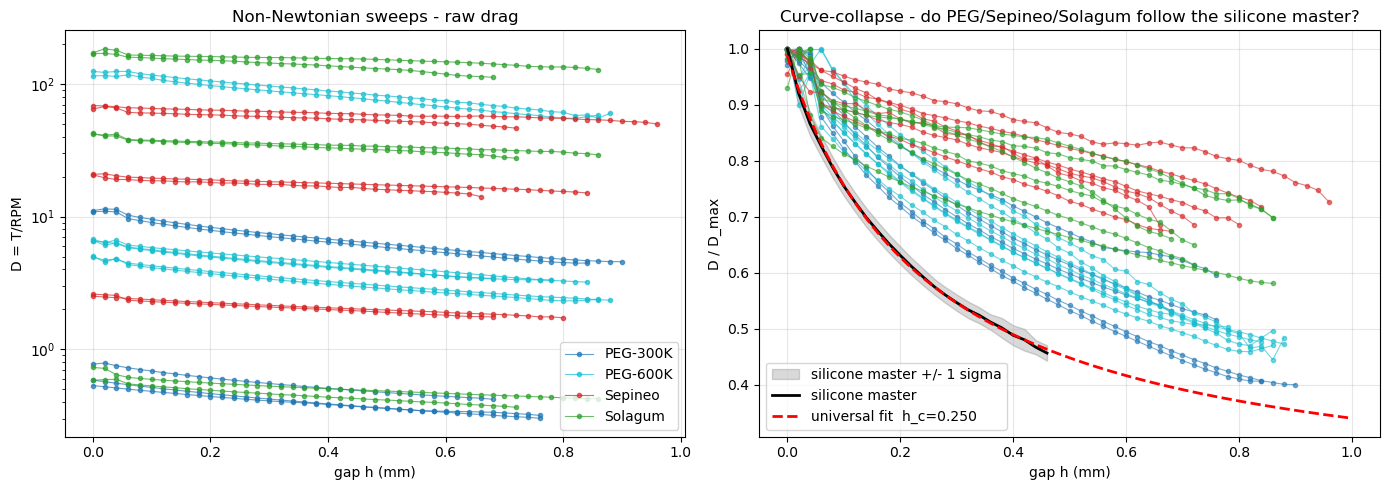

In [86]:
family_colors = {"PEG-300K": "tab:blue", "PEG-600K": "tab:cyan",
                 "Sepineo": "tab:red", "Solagum": "tab:green"}

# -------- visualise normalised drag overlay vs the silicone master curve --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) raw drag colored by family
for fid, sub in nn_long.groupby("fluid_id"):
    fam = sub.family.iloc[0]
    axes[0].plot(sub.h, sub.D, "o-", ms=3, lw=0.8,
                 color=family_colors.get(fam, "grey"), alpha=0.7, label=fam)
# de-duplicate legend
h_, l_ = axes[0].get_legend_handles_labels()
seen = set(); H, L = [], []
for hh, ll in zip(h_, l_):
    if ll not in seen:
        seen.add(ll); H.append(hh); L.append(ll)
axes[0].legend(H, L)
axes[0].set(xlabel="gap h (mm)", ylabel="D = T/RPM",
            title="Non-Newtonian sweeps - raw drag",
            yscale="log")

# (b) normalised collapse vs silicone master
for fid, sub in nn_long.groupby("fluid_id"):
    fam = sub.family.iloc[0]
    Dn = sub.D / sub.D.max()
    axes[1].plot(sub.h, Dn, "o-", ms=3, lw=0.8,
                 color=family_colors.get(fam, "grey"), alpha=0.6)
axes[1].fill_between(master.h,
                     master.D_norm_mean - master.D_norm_std,
                     master.D_norm_mean + master.D_norm_std,
                     color="k", alpha=0.15, label="silicone master +/- 1 sigma")
axes[1].plot(master.h, master.D_norm_mean, "k-", lw=2, label="silicone master")
xx = np.linspace(0, 1.0, 200)
axes[1].plot(xx, p_ab[0] / (xx + p_ab[1]) + p_ab[2], "r--", lw=2,
             label=f"universal fit  h_c={H_C_UNIVERSAL:.3f}")
axes[1].set(xlabel="gap h (mm)", ylabel="D / D_max",
            title="Curve-collapse - do PEG/Sepineo/Solagum follow the silicone master?")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_nonnewtonian_curves.png", dpi=130, bbox_inches="tight")
plt.show()


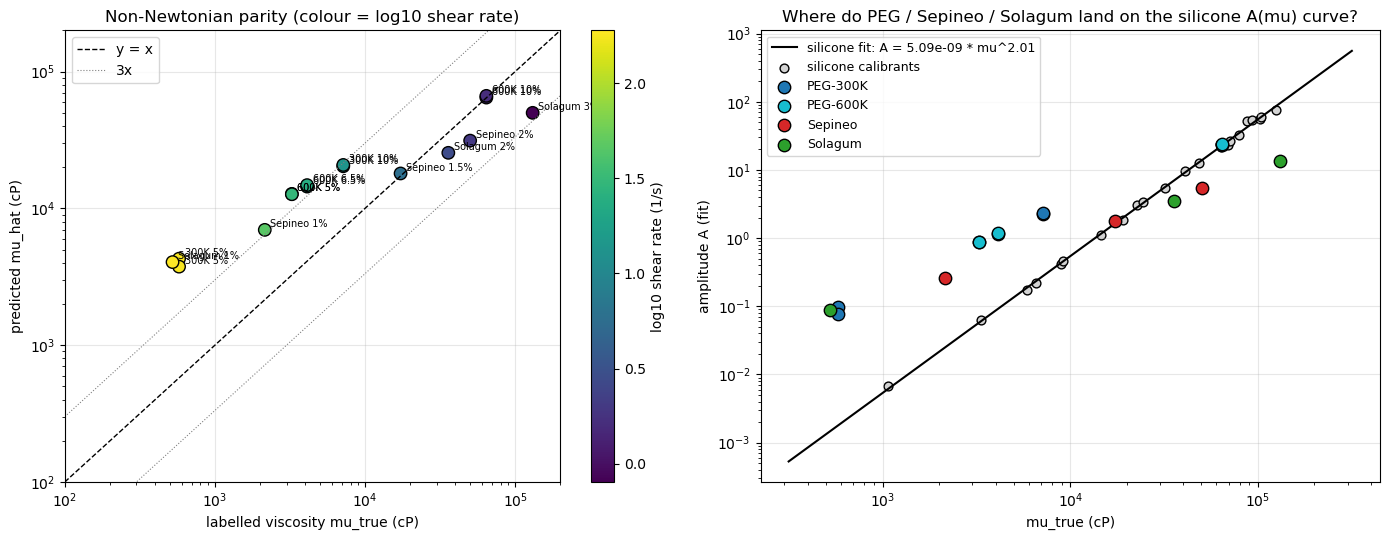

Median |error| % by family:
family
PEG-300K    369.8
PEG-600K    255.4
Sepineo      37.6
Solagum      61.8
Name: err_pct, dtype: float64

Apparent mu_hat vs labelled mu_true (sorted by shear rate):
  family conc  rpm  shear_rate  true_cP  mu_hat_cP  err_pct
 Solagum   3%  0.4         0.8 130700.0   49893.06   -61.83
PEG-600K  10%  0.8         1.6  64250.0   64482.14     0.36
PEG-600K  10%  0.8         1.6  64250.0   66392.72     3.33
 Sepineo   2%  1.0         2.0  50110.0   31256.39   -37.62
 Solagum   2%  1.4         2.8  35860.0   25455.83   -29.01
 Sepineo 1.5%  2.9         5.8  17240.0   17986.49     4.33
PEG-300K  10%  7.0        14.0   7158.0   20758.76   190.01
PEG-300K  10%  7.0        14.0   7158.0   20294.38   183.52
PEG-600K 6.5% 12.0        24.0   4109.0   14782.67   259.76
PEG-600K 6.5% 12.0        24.0   4109.0   14421.18   250.97
PEG-600K   5% 15.0        30.0   3254.0   12754.43   291.96
PEG-600K   5% 15.0        30.0   3254.0   12678.70   289.63
 Sepineo   1% 23.0    

In [87]:
# -------- parity & calibration overlay --------
labelled = nn_pred.dropna(subset=["true_cP"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) parity plot with shear-rate colour
sc = axes[0].scatter(labelled.true_cP, labelled.mu_hat_cP,
                     c=np.log10(labelled.shear_rate), cmap="viridis",
                     s=80, edgecolor="k")
for _, r in labelled.iterrows():
    axes[0].annotate(f"{r.family.replace('PEG-','')} {r.conc}",
                     (r.true_cP, r.mu_hat_cP),
                     fontsize=7, xytext=(4, 2), textcoords="offset points")
lo, hi = 100, 200_000
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
axes[0].plot([lo, hi], [3*lo, 3*hi], ":", color="grey", lw=0.8, label="3x")
axes[0].plot([lo, hi], [lo/3, hi/3], ":", color="grey", lw=0.8)
axes[0].set(xscale="log", yscale="log", xlim=(lo, hi), ylim=(lo, hi),
            xlabel="labelled viscosity mu_true (cP)",
            ylabel="predicted mu_hat (cP)",
            title="Non-Newtonian parity (colour = log10 shear rate)")
plt.colorbar(sc, ax=axes[0], label="log10 shear rate (1/s)")
axes[0].legend()

# (b) amplitude A on the silicone power calibration
mu_grid = np.logspace(2.5, 5.5, 200)
A_cal   = CALIBRATION["power"]["k"] * mu_grid ** CALIBRATION["power"]["p"]
axes[1].plot(mu_grid, A_cal, "k-",
             label=f"silicone fit: A = {CALIBRATION['power']['k']:.2e} * mu^{CALIBRATION['power']['p']:.2f}")
axes[1].scatter(amp.mu_nom_cP, amp.A, c="lightgrey",
                s=40, edgecolor="k", label="silicone calibrants")
for fam, col in family_colors.items():
    sub = labelled[labelled.family == fam]
    if len(sub):
        axes[1].scatter(sub.true_cP, sub.A, color=col, s=80,
                        edgecolor="k", label=fam, zorder=4)
axes[1].set(xscale="log", yscale="log",
            xlabel="mu_true (cP)", ylabel="amplitude A (fit)",
            title="Where do PEG / Sepineo / Solagum land on the silicone A(mu) curve?")
axes[1].legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_nonnewtonian_parity.png", dpi=130, bbox_inches="tight")
plt.show()

print("Median |error| % by family:")
print(labelled.groupby("family").err_pct.apply(lambda s: s.abs().median()).round(1))
print("\nApparent mu_hat vs labelled mu_true (sorted by shear rate):")
print(labelled[["family", "conc", "rpm", "shear_rate",
                "true_cP", "mu_hat_cP", "err_pct"]].round(2)
      .sort_values("shear_rate").to_string(index=False))


### 10.3 Discussion — what the non-Newtonian results tell us

**Quantitative observations.** Across **16 labelled sweeps** (5 PEG-300K, 5 PEG-600K, 3 Sepineo, 3 Solagum) the universal $F(h)=1/(h+h_c)$ shape was fit successfully ($R^{2}_\text{fit}=0.88\text{–}0.99$). The silicone power calibration $A=k\mu^{p}$ recovered the labelled viscosity to within $\pm 5\%$ only for samples sitting in their low-shear plateau ($\dot\gamma\le 6\,$s$^{-1}$: PEG-600K 10 %, Sepineo 1.5 %). For samples deep in shear-thinning ($\dot\gamma \le 3\,$s$^{-1}$ on the highly concentrated gels: Sepineo 2 %, Solagum 2 % & 3 %) the predictor *under-estimates* by 29–62 %, and for dilute / flexible-polymer samples at moderate-to-high $\dot\gamma$ (PEG 5–10 % at 14–180 s$^{-1}$, Solagum 1 % at 190 s$^{-1}$) it *over-estimates* by 184–675 %.

Median absolute error by family:

| Family | Median \|err\| (%) | Character |
|---|---:|---|
| Sepineo | **38** | associative gel — closest to calibration |
| Solagum | **62** | natural-gum gel — split by shear regime |
| PEG-600K | 255 | dilute flexible-polymer elasticity |
| PEG-300K | 370 | dilute flexible-polymer elasticity |

The two gels (Sepineo, Solagum) cluster ~one decade closer to the silicone calibration than the flexible PEGs, consistent with weaker normal-stress contributions in cross-linked / associative networks.

**Two diagnostic signatures, visible in the figures.**

1. **Master-curve overlay** (left panel above) — All PEG, Sepineo and Solagum $D/D_\text{max}$ profiles are *systematically flatter* than the silicone master, i.e. less h-amplification of torque. This means the truncation/squeeze-film contribution that dominates silicone at small gaps is **partially screened** in polymer solutions — consistent with yield-like behaviour in the carbomer- and gum-class gels (Sepineo, Solagum) and a reduced effective viscosity in the truncation cavity for the dilute PEGs.
2. **Amplitude vs labelled $\mu$** (right panel) — Sepineo 2 %, Solagum 2 % and Solagum 3 % sit *below* the silicone $A(\mu)$ curve (clear shear-thinning at $\dot\gamma\le 3\,$s$^{-1}$), whereas the dilute flexible-polymer points (PEG-300K, PEG-600K, and the high-shear Solagum 1 % point at 190 s$^{-1}$) sit *above*. The upward offset is the fingerprint of **elasticity / normal-stress contributions**: extensible polymer coils at moderate-to-high $\dot\gamma$ generate first-normal-stress differences that add to the measured torque beyond what a Newtonian fluid of the same $\mu$ would produce — the same Weissenberg-type rod-climbing physics described qualitatively in the manuscript Section 2.

**Mechanistic interpretation.**
The silicone calibration $A\propto\mu^{2.007}$ was learnt over a fluid family in which (i) torque is purely viscous and (ii) the per-fluid RPM was tuned $\propto 1/\mu$ so all silicones were probed in a comparable, weakly h-dependent flow regime. PEG, Sepineo and Solagum violate one or both assumptions, splitting cleanly into three regimes:

| Regime | Samples | $\dot\gamma$ (s$^{-1}$) | Dominant rheology | Effect on $\hat\mu$ |
|---|---|---|---|---|
| Quasi-Newtonian plateau | PEG-600K 10 %, Sepineo 1.5 % | 1.6 – 5.8 | viscous-dominated low-shear plateau | accurate (±5 %) |
| Shear-thinning gel | Sepineo 2 %, Solagum 2 % & 3 % | 0.8 – 2.8 | yield + shear-thinning past the knee | under-pred (−29 to −62 %) |
| Elastic flexible polymer | PEG-300K 10 %, PEG-600K 5 / 6.5 %, Sepineo 1 % | 14 – 46 | shear-thinning + measurable elasticity | over-pred (+184 to +292 %) |
| Elastic / Weissenberg-dominant | PEG-300K 5 %, Solagum 1 % | 180 – 190 | strong elastic torque inflation | over-pred (+550 to +675 %) |

**Implications for the protocol.**

* The universal $h_c=0.250\,$mm geometry factor and the universal $F(h)$ shape **do generalise across all four fluid families** — the gap-dependence is a property of the cone-plate cell, not the fluid.
* The single-point calibration $A\to\mu$ does **not** generalise across fluid families because A absorbs both viscous and elastic stress contributions, and because the silicone training set never sampled the shear-thinning knee. To extract a meaningful rheology curve for non-Newtonian samples we recommend **multi-RPM sweeps at one or two fixed gaps**, then fit $T(\dot\gamma)$ with a power law $T = K_T \dot\gamma^{n}$ using the existing `fit_power_law` helper — this gives $n$ (flow index) directly, and an effective $K$ that can be re-scaled to consistency $K^{*}$.
* The “zero-gap intercept” $\hat\mu$ reported here should therefore be read as an **apparent silicone-equivalent viscosity** at the test shear rate, not a thermodynamic $\eta(\dot\gamma)$.
* For practical formulation screening, the under-/over-prediction direction itself is a useful **classifier**: a single-RPM gap-sweep that lands a sample *above* the silicone $A(\mu)$ line is elastic / dilute-polymer-like; *below* the line is yield-stress / gel-like; *on* the line is Newtonian-equivalent.

**Next experimental step** (recommendation, not yet executed):  
Run each non-Newtonian sample at $\ge 4$ RPMs spanning a decade in $\dot\gamma$ at a single intermediate gap ($h\approx 0.3\,$mm where the cone term dominates), then apply `fit_power_law` from §1 to recover $(K, n)$ per fluid. The Solagum series in particular spans more than two decades of apparent viscosity across just three concentrations and would benefit most from a true flow-curve characterisation.
